# End to End periodontal disease detection binary classification

## 1. Define the problem

Idetifying the presence of a periodontal disease inside of an xray.

## 2. Data

The data we're using from Kaggle: https://www.kaggle.com/datasets/kasmira/dentalpanoramic/data

## 3. Evaluation

File with prediction probability of having Periodontal disease:

## 4. Features
* We are using unstructured data. Therefore we will rely on a Deep Learning/Transfer Learning model.
* There are a total of 100 images in our dataset
  * 50 X-Ray images from Non-Perio patients
  * 50 X-Ray images from Perio patients

## Get our workspace ready by importing all of our tools

In [1]:
import pandas as pd
import numpy as np
import tensorflow as tf
import tensorflow_hub as hub
import keras
import os, datetime, hashlib, pytz
from pathlib import Path
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

## Getting our data ready
* Computers do not understand images and test.
* They only understand numbers.
* We will turn our images into a numerical structure and associate them with a binary classification label
  * 0: Non-Periodontal
  * 1: Periodontal

In [2]:
# Unzip zipped data folder from google drive
# !unzip "drive/MyDrive/Colab Notebooks/perio-detection/archive.zip" -d "drive/MyDrive/Colab Notebooks/perio-detection/"

In [3]:
# Write function(s) to rename our files to a more representative version of each file
from pathlib import Path
import hashlib


def hash_file(file_path: Path, algorithm: str = "sha256", chunk_size: int = 8192) -> str:
    hasher = hashlib.new(algorithm)

    with file_path.open("rb") as f:
        while chunk := f.read(chunk_size):
            hasher.update(chunk)

    return hasher.hexdigest()


def rename_files_to_hash(folder_path: str, algorithm: str = "sha256"):
    folder = Path(folder_path)

    if not folder.exists() or not folder.is_dir():
        raise ValueError(f"{folder_path} is not a valid directory")

    for file_path in folder.iterdir():
        if file_path.is_file():
            file_hash = hash_file(file_path, algorithm)

            # No file extension
            new_path = folder / file_hash

            # Handle rare hash collision case
            counter = 1
            while new_path.exists():
                new_path = folder / f"{file_hash}_{counter}"
                counter += 1

            file_path.rename(new_path)
            print(f"Renamed: {file_path.name} → {new_path.name}")


In [4]:
#rename_files_to_hash("drive/MyDrive/Colab Notebooks/perio-detection/dental-panoramic/penyakit-non-periodontal")

In [5]:
#rename_files_to_hash("drive/MyDrive/Colab Notebooks/perio-detection/dental-panoramic/penyakit-periodontal")

### Create our dataframe

In [6]:
def create_mappings_dict(folderpath, binary_class, name_to_label_mapping):
  for file in os.listdir(folderpath):
    file = file.split(".")[0]
    name_to_label_mapping[file] = binary_class

name_to_label_mapping = {}
create_mappings_dict("drive/MyDrive/Colab Notebooks/perio-detection/dental-panoramic/penyakit-non-periodontal",0,name_to_label_mapping)
create_mappings_dict("drive/MyDrive/Colab Notebooks/perio-detection/dental-panoramic/penyakit-periodontal",1,name_to_label_mapping)

df = pd.DataFrame(list(name_to_label_mapping.items()), columns=["id", "value"])

In [7]:
df.value.value_counts()

,count
value,
1,50
0,49


### Creating our training and validation sets

In [8]:
filenames = ["drive/MyDrive/Colab Notebooks/perio-detection/dental-panoramic/all-images/"+fname+".jpg" for fname in df.id]
binary_classifications = df.value

In [9]:
x_train,x_val,y_train,y_val = train_test_split(filenames, binary_classifications, test_size=0.05, random_state=42)

### Preprocessing images (turning images into tensors)
To preprocess our images into Tensors we'e going to write a function which does:

* Take an image filepath as input
* Use TensorFlow to read the file and save it to a variable 'image'
* Turn our 'image' into Tensors
* Normalize our image (convert color channels from 0-255 to 0-1)
* Resize the 'image' to be a shape of (224,224)
* Return the modified 'image'

In [10]:
# Define image size in pixels (Recommended size for the model we will be uisng)
IMG_SIZE = 224

# Create a function to preprocess the images
def process_image(filepath, image_size=IMG_SIZE):
  try:
    # Read image file
    image = tf.io.read_file(filepath)

    # Turn image into numerica tensors with a 3 color channel (Red, Green, Blue)
    image = tf.image.decode_jpeg(image,channels=3)

    # Convert the color channel values from 0-255 to 0-1 values
    image = tf.image.convert_image_dtype(image, tf.float32)

    # Resize image
    image = tf.image.resize(image, size=[image_size,image_size])

    return image
  except:
    print(f"Error occurred while processing image at: {filepath}")



### We're going to turn our data into batches.

Let's say youre trying to process 10,000+ images in one go, they might not all fit into memory.

So that's why we will process 32 images at a time (batches of size 32). Adjust batch size as needed.

In order to use TF effectively, we need our data in the form of Tensor tuples (image, label)

In [11]:
# Create a simple function to return a tuple of image_tensors (image in numerical structure) and its label (image, tuple)
def get_image_tuple(image_path, label):
  return (process_image(image_path), [label])

In [12]:
# Define batch size
BATCH_SIZE = 32

# Create function to turn our data into batches
def create_data_batches(x, y=None, BATCH_SIZE=BATCH_SIZE, validation_data=False, test_data=False):
  """
    Creates batches out of image (x) and label (y) pairs
    Shuffle the data if its training data but doesnt shuffle if its validation data.
    Also accepts test data as input (no labels)
  """
  if test_data:
    print("Creating test data batches...")
    data = tf.data.Dataset.from_tensor_slices(tf.constant(x)) # turns the image (x) into tensors, no labels
    data_batch = data.map(process_image).batch(BATCH_SIZE) # creates tensors batches of pre-determined size using the process_image() method created above
    return data_batch
  elif validation_data:
    print("Creating validation data batches...")
    data = tf.data.Dataset.from_tensor_slices((
                                    tf.constant(x),  # turns the image (x) into tensors
                                    tf.constant(y)))  # turns the label into tensors
    data_batch = data.map(get_image_tuple).batch(BATCH_SIZE)
    return data_batch
  else:
    print("Creating training data batches...")
    data = tf.data.Dataset.from_tensor_slices((tf.constant(x),
                                              tf.constant(y)))

    # Shuffle pathnames and labels before mapping image processor function is faster than shuffling images
    data = data.shuffle(buffer_size=len(x))

    # Create (image, label tuples) -> Also turns the image path into preprocessed image
    data = data.map(get_image_tuple)

    # Turn training data into batches
    data_batch = data.batch(BATCH_SIZE)

    return data_batch


In [44]:
# Create our training and validation data batches
train_data_batch = create_data_batches(x=x_train, y=y_train)
validation_data_batch = create_data_batches(x=x_val, y=y_val, validation_data=True)

Creating training data batches...
Creating validation data batches...


In [45]:
train_data_batch

<_BatchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, 1), dtype=tf.int64, name=None))>

## Building a model

In [46]:
COLOR_CHANNELS=3

# Every model needs to know the shape of the input data
INPUT_SHAPE = [None, IMG_SIZE,IMG_SIZE,COLOR_CHANNELS]

# Models also need to know the shape of the output data which in this case will be a list of a single integer indicating the existence of periodontal disease.
OUTPUT_SHAPE = 1

# Model URL
# MobileNetV2 is a lightweight Convolutional Neural Network (CNN) designed for mobile and embedded vision applications.
MODEL_URL = "https://www.kaggle.com/models/google/mobilenet-v2/TensorFlow2/100-224-feature-vector/2"


In [124]:
@keras.saving.register_keras_serializable(package="Custom")
class HubLayer(keras.layers.Layer):
    def __init__(self, model_url=None, **kwargs):
        # 1. Let Keras handle 'trainable' and 'name' from kwargs
        super().__init__(**kwargs)
        self.model_url = model_url

        # 2. Re-initialize the internal model if we have a URL
        if self.model_url:
            model_path = hub.resolve(self.model_url)
            # Match the internal layer's trainability to this layer's state
            self.hub_model = keras.layers.TFSMLayer(
                model_path,
                call_endpoint='serving_default',
                trainable=self.trainable
            )

    def call(self, inputs):
        outputs = self.hub_model(inputs)
        return outputs['feature_vector']

    def get_config(self):
        # 3. Always include custom parameters in the config
        config = super().get_config()
        config.update({"model_url": self.model_url})
        return config

    @classmethod
    def from_config(cls, config):
        # 4. Standard from_config implementation
        return cls(**config)

def create_model(input_shape=INPUT_SHAPE, output_shape=OUTPUT_SHAPE, model_url=MODEL_URL):
    inputs = keras.Input(shape=input_shape[1:])

    # Ensure model_url is passed so it's saved in the config
    x = HubLayer(model_url=model_url, trainable=False)(inputs)

    predictions = keras.layers.Dense(units=output_shape, activation="sigmoid")(x)
    model = keras.Model(inputs=inputs, outputs=predictions)

    model.compile(
        loss=keras.losses.BinaryCrossentropy(),
        optimizer=keras.optimizers.Adam(),
        metrics=["accuracy"]
    )
    return model

In [125]:
model = create_model()

In [126]:
model.summary()

Model: "functional_23"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_25 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ hub_layer_9 (HubLayer)          │ (None, 1280)           │     2,257,984 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_24 (Dense)                │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,259,265 (8.62 MB)

 Trainable params: 1,281 (5.00 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## Creating callbacks

We'll create 2 callbacks
1. LearningRate which helps a model "settle" into a global minimum. High learning rates help at the start to find the general area of a solution, while smaller rates later on prevent the model from "overshooting".
2. Early stopping which prevents model from training for too long without showing much improvement

### Learning rate exponential decay function

In [127]:
def sched(epoch, lr):
    # Decay by 10% every 10 epochs
    if epoch > 0 and epoch % 10 == 0:
        return lr * 0.9
    return lr

### Early Stopping

In [128]:
early_stopping = keras.callbacks.EarlyStopping(monitor="val_accuracy", patience=10)

## Training a model

In [129]:
# Create a function to train our model
def train_model(model, training_data, validation_data):
  lr_callback = tf.keras.callbacks.LearningRateScheduler(sched)

  model.fit(x=training_data, epochs=100, validation_data=validation_data, validation_freq=1, callbacks=[lr_callback, early_stopping])

  return model

* Create a model using the create_model function
* Pass the created model to the train_model function along with
  * Training data batch
  * Validation Data Batch

In [130]:
# call the train model function and pass in
model = create_model()
train_model(model, train_data_batch, validation_data_batch)

Epoch 1/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 15s 2s/step - accuracy: 0.4808 - loss: 1.0719 - val_accuracy: 0.6000 - val_loss: 0.5767 - learning_rate: 0.0010
Epoch 2/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 2s/step - accuracy: 0.5802 - loss: 0.7330 - val_accuracy: 0.6000 - val_loss: 0.5887 - learning_rate: 0.0010
Epoch 3/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5682 - loss: 0.7136 - val_accuracy: 0.6000 - val_loss: 0.5715 - learning_rate: 0.0010
Epoch 4/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.5766 - loss: 0.6840 - val_accuracy: 1.0000 - val_loss: 0.5193 - learning_rate: 0.0010
Epoch 5/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 12s 2s/step - accuracy: 0.6884 - loss: 0.6053 - val_accuracy: 0.6000 - val_loss: 0.5260 - learning_rate: 0.0010
Epoch 6/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 7s 2s/step - accuracy: 0.7381 - loss: 0.5721 - val_accuracy: 0.6000 - val_loss: 0.5447 - learning_rate: 0.0010
Epoch 7/100
3/3 ━━━━━━━━━━━━━━━━━━━━ 9s 2s/step - accuracy: 0.7395 - loss: 0.5608 - val_accuracy: 0.6000 - v

<Functional name=functional_24, built=True>

## Saving Model

In [131]:
def save_model(model, suffix):
  saved_models_path="drive/MyDrive/Colab Notebooks/perio-detection/saved_models"
  model_dir=os.path.join(saved_models_path, datetime.datetime.now().strftime("%Y%m%d-%H%M%s"))

  model_path = model_dir + "-" + suffix + ".keras"

  print(f"Saving model to: {model_path}...")

  model.save(model_path)

  return model_path

## Loading model

In [132]:
# Create a function to load a model
def load_model(model_path):
  print(f"Loading model from: {model_path}...")
  loaded_model = tf.keras.models.load_model(model_path, custom_objects={"HubLayer": HubLayer})
  return loaded_model

In [133]:
save_model(model,"100_images_mobilenetv2")

Saving model to: drive/MyDrive/Colab Notebooks/perio-detection/saved_models/20260307-19421772912551-100_images_mobilenetv2.keras...


'drive/MyDrive/Colab Notebooks/perio-detection/saved_models/20260307-19421772912551-100_images_mobilenetv2.keras'

In [134]:
loaded_model = load_model("drive/MyDrive/Colab Notebooks/perio-detection/saved_models/20260307-19421772912551-100_images_mobilenetv2.keras")

Loading model from: drive/MyDrive/Colab Notebooks/perio-detection/saved_models/20260307-19421772912551-100_images_mobilenetv2.keras...


## Making predictions on the test data

To make predictions on never seen data (the 5% of the data set that we did not train on)

In [135]:
# Creating test data batches
test_data_batches = create_data_batches(x=x_val,test_data=True)

# Making predictions
test_predictions = loaded_model.predict(test_data_batches)

Creating test data batches...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 866ms/step


In [136]:
test_predictions

array([[0.74909353],
       [0.4590142 ],
       [0.80234116],
       [0.6269237 ],
       [0.8330572 ]], dtype=float32)

In [137]:
test_predictions = model.predict(test_data_batches)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


## View X-Rays and their probabilities

In [138]:

def plot_images(test_data_batches, test_predictions, validation_data, figsize=(5,5)):
  test_images = []
  # Loop through unbatched data
  for image in test_data_batches.unbatch().as_numpy_iterator():
    test_images.append(image)

  plt.figure(figsize=figsize)
  for i, image in enumerate(test_images):
    plt.subplot(1,len(test_images),i+1)
    plt.xticks([])
    plt.xticks([])
    if isinstance(validation_data, list):
      if validation_data[i] == 1:
        results = "Perio"
      else:
        results = "Non-Perio"
    else:
      if validation_data.to_numpy()[i] == 1:
        results = "Perio"
      else:
        results = "Non-Perio"
    title = "Prediction: " + str(test_predictions[i][0]*100) + "% | Actual: " + results
    plt.title(title)
    plt.imshow(image)

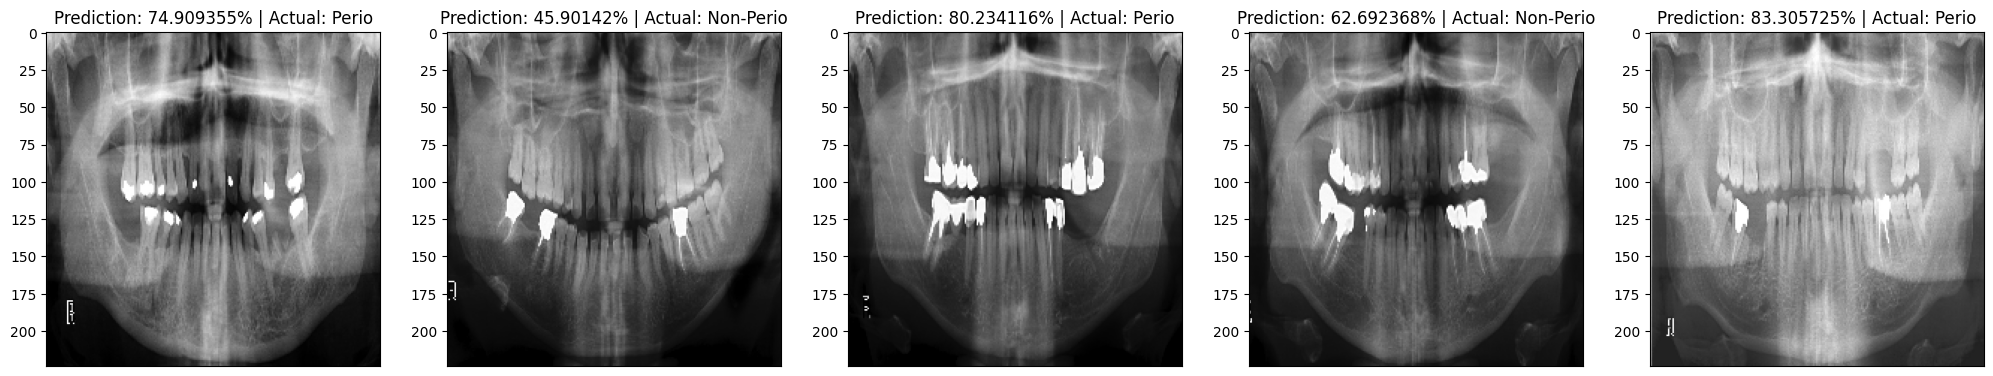

In [139]:
plot_images(test_data_batches, test_predictions, y_val, figsize=(25,25))

In [140]:


demo_file="drive/MyDrive/Colab Notebooks/perio-detection/demo/perio_demo_2.jpg"
demo_file_data_batch = create_data_batches(x=[demo_file],test_data=True)

demo_file_prediction = loaded_model.predict(demo_file_data_batch)




Creating test data batches...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 1s/step


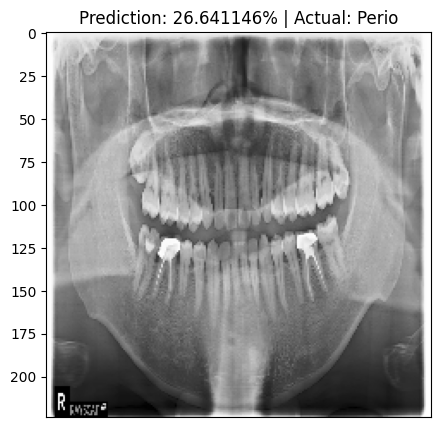

In [141]:
plot_images(demo_file_data_batch, demo_file_prediction, [1])